# House Price Prediction using Machine Learning

Week 5 Assignment - Introduction to Machine Learning in Data Science

In [10]:
# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.impute import SimpleImputer

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [11]:

df = pd.read_csv('BostonHousing.csv')

df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [12]:
print("\nDataset Information")
print(df.info())




Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None


In [13]:
print("\nMissing Values")
print(df.isnull().sum())




Missing Values
crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [14]:
print("\nStatistical Summary")
df.describe()


Statistical Summary


,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


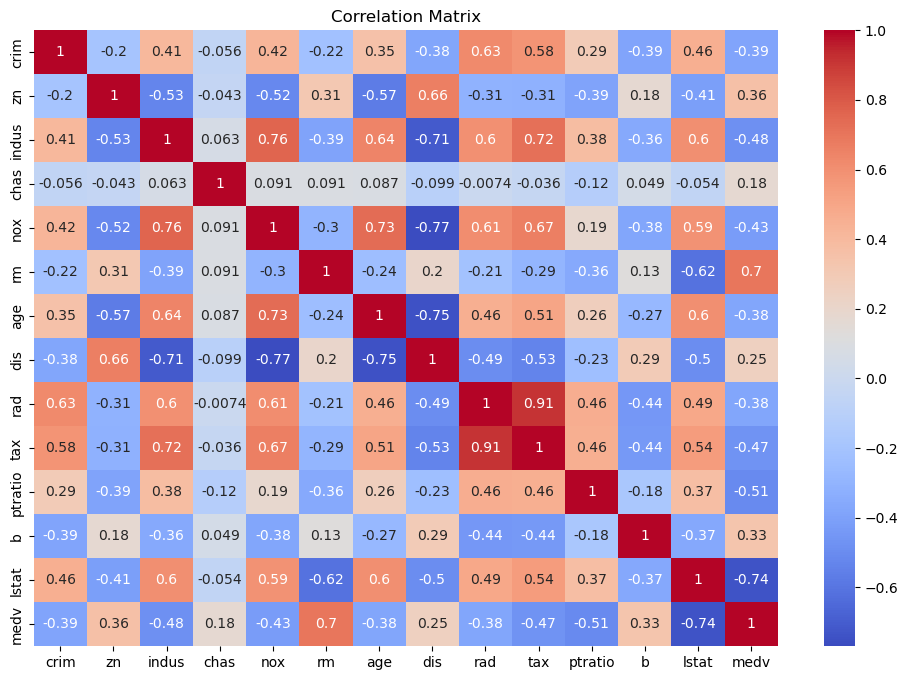

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")
plt.show()

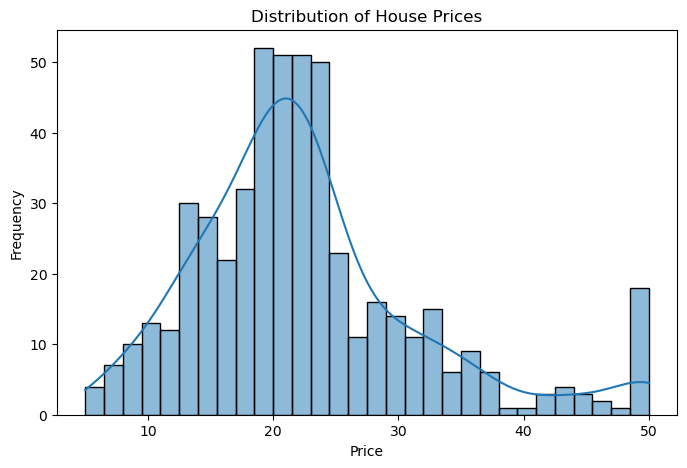

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['medv'],
    bins=30,
    kde=True
)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.show()

In [17]:
X = df.drop('medv', axis=1)

y = df['medv']

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (506, 13)
Target Shape: (506,)


In [18]:
imputer = SimpleImputer(strategy='mean')

X = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns
)

print("\nMissing Values After Imputation")
print(X.isnull().sum())


Missing Values After Imputation
crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
dtype: int64


In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (404, 13)
Testing Data: (102, 13)


In [20]:

model = LinearRegression()

model.fit(X_train, y_train)

print("\nModel Training Completed Successfully")


Model Training Completed Successfully


In [21]:
y_pred = model.predict(X_test)

print("Predictions Generated Successfully")

Predictions Generated Successfully


In [22]:
rmse = np.sqrt(
    mean_squared_error(y_test, y_pred)
)

print("Root Mean Squared Error (RMSE):", rmse)

Root Mean Squared Error (RMSE): 4.940124005341007


In [23]:
r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.6672089705941882


In [24]:
comparison = pd.DataFrame({
    'Actual Price': y_test,
    'Predicted Price': y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
173,23.6,28.981419
274,32.4,36.014232
491,13.6,14.824309
72,22.8,25.022936
452,16.1,18.770774
76,20.0,23.250889
316,17.8,17.659214
140,14.0,14.331216
471,19.6,23.017996
500,16.8,20.619237


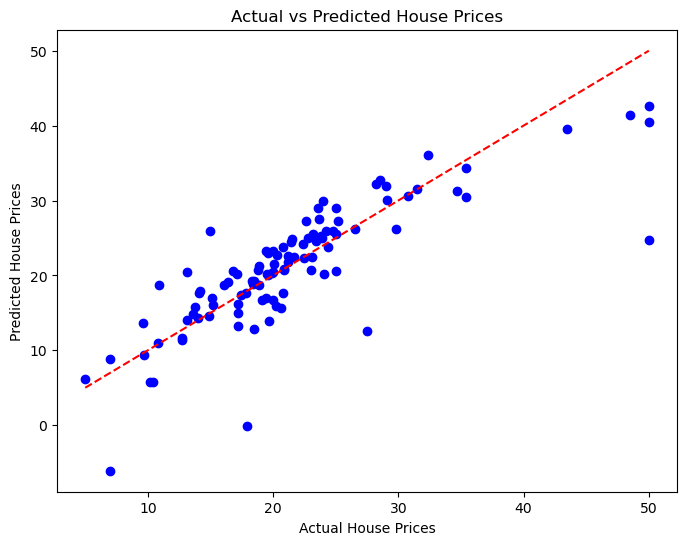

In [25]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    color='blue'
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.show()

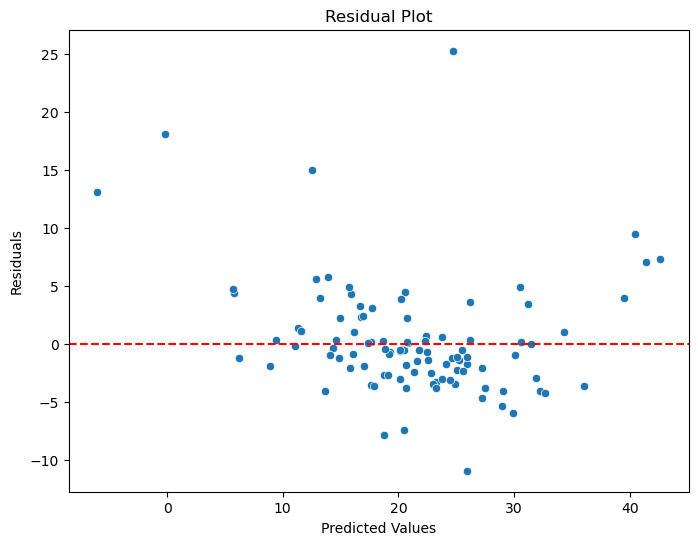

In [26]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [27]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient
5,rm,4.429193
3,chas,2.787586
8,rad,0.262753
2,indus,0.041726
1,zn,0.030209
11,b,0.012349
6,age,-0.006109
9,tax,-0.010647
0,crim,-0.113051
12,lstat,-0.508973


In [28]:
print("="*50)
print("MODEL PERFORMANCE SUMMARY")
print("="*50)

print("RMSE :", round(rmse,2))
print("R2 Score :", round(r2,4))

MODEL PERFORMANCE SUMMARY
RMSE : 4.94
R2 Score : 0.6672


In [29]:
print("\n" + "="*50)
print("HOUSE PRICE PREDICTION SUMMARY")
print("="*50)

print(f"RMSE      : {rmse:.2f}")
print(f"R² Score  : {r2:.4f}")

print("\nInterpretation:")
print("• Lower RMSE indicates better prediction accuracy.")
print("• Higher R² Score indicates better model performance.")

print("\nSuggested Improvements:")
print("1. Random Forest Regressor")
print("2. Gradient Boosting Regressor")
print("3. XGBoost Regressor")
print("4. Hyperparameter Tuning")
print("5. Cross Validation")
print("6. Feature Engineering")

print("\nProject Completed Successfully.")


HOUSE PRICE PREDICTION SUMMARY
RMSE      : 4.94
R² Score  : 0.6672

Interpretation:
• Lower RMSE indicates better prediction accuracy.
• Higher R² Score indicates better model performance.

Suggested Improvements:
1. Random Forest Regressor
2. Gradient Boosting Regressor
3. XGBoost Regressor
4. Hyperparameter Tuning
5. Cross Validation
6. Feature Engineering

Project Completed Successfully.
